In [5]:
import pandas as pd

# Loading the dataset
df = pd.read_csv('q3_retail_promotions.csv')

# Converting transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extracting features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # Monday=0, Sunday=6
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Saving the transformed dataframe to a new CSV file
df.to_csv('q3_retail_promotions_engineered.csv', index=False)

# Just calling .head() at the end of a cell will render a pretty HTML table
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10)

,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


In [7]:
import pandas as pd

# Loading the engineered dataset
df = pd.read_csv('q3_retail_promotions_engineered.csv')

# Ensuring transaction_date is datetime and sort temporally
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df = df.sort_values(by='transaction_date').reset_index(drop=True)

# Calculating split index for 80% train / 20% test
split_idx = int(len(df) * 0.8)

# Splitting the data
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

train_df.to_csv('q3_train.csv', index=False)
test_df.to_csv('q3_test.csv', index=False)

#Why is a random split inappropriate for time-ordered data?
Using a random split on time-series or time-ordered data is fundamentally flawed and introduces Data Leakage:

1. If we randomly shuffle and split the data, the training set will contain records from the future. The model will inadvertently "learn" from future events to predict past events, artificially inflating its performance metrics.

2. Time-series data often contains trends, seasonality, and autocorrelation. A random split destroys the natural chronological sequence needed to learn these patterns properly.

3. The goal of testing a model is to simulate how it will perform in production. In the real world, you only have historical data to predict the unknown future.

In [10]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


train_df = pd.read_csv('q3_train.csv')
test_df = pd.read_csv('q3_test.csv')

# Separating features (X) and target (y)
X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

# 3. Defining the categorical and numerical feature groupings
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
                      'year', 'month', 'day_of_week', 'is_month_end']

# 4. Creating the preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

# 5. Building the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# 6. Fitting the pipeline on the TRAINING SET ONLY to prevent data leakage
pipeline.fit(X_train)

# 7. Applying the fitted pipeline to both train and test sets
X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

# Getting the numerical feature names
num_cols = numerical_features

# Getting the newly generated categorical feature names from the OneHotEncoder
cat_cols = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combining both lists to get all 19 column names
all_cols = num_cols + list(cat_cols)

# Converting the transformed NumPy array back into a pandas DataFrame
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=all_cols)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_cols)

# Printing the shapes to see the feature expansion
print(f"Original X_train shape: {X_train.shape}")
print(f"Transformed X_train shape: {X_train_transformed_df.shape}")

# Displaying the first 5 rows
print("\nSample of transformed training data:")
display(X_train_transformed_df.head()) # Use print() instead of display() if you are not in Jupyter

Original X_train shape: (960, 11)
Transformed X_train shape: (960, 19)

Sample of transformed training data:


,store_id,is_weekend,is_festival,competition_density,year,month,day_of_week,is_month_end,promotion_type_bogo,promotion_type_category_offer,promotion_type_flat_discount,promotion_type_free_gift,promotion_type_loyalty_points,location_type_rural,location_type_semi-urban,location_type_urban,store_size_large,store_size_medium,store_size_small
0,0.199960,1.590412,-0.361583,0.042569,-1.071337,-1.349015,0.999033,-0.506502,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.398564,1.590412,2.765619,-1.443485,-1.071337,-1.349015,0.999033,-0.506502,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.842555,1.590412,-0.361583,0.414083,-1.071337,-1.349015,1.514110,-0.506502,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.564551,1.590412,-0.361583,0.785596,-1.071337,-1.349015,1.514110,-0.506502,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,1.728983,-0.628768,-0.361583,-0.700458,-1.071337,-1.349015,-1.576348,-0.506502,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


Linear Regression - RMSE: 27.12, MAE: 21.05
Random Forest     - RMSE: 30.84, MAE: 24.31

Top 5 Most Influential Features:
                Feature  Importance
2           is_festival    0.173413
18     store_size_small    0.166752
15  location_type_urban    0.108505
6           day_of_week    0.080552
1            is_weekend    0.067103


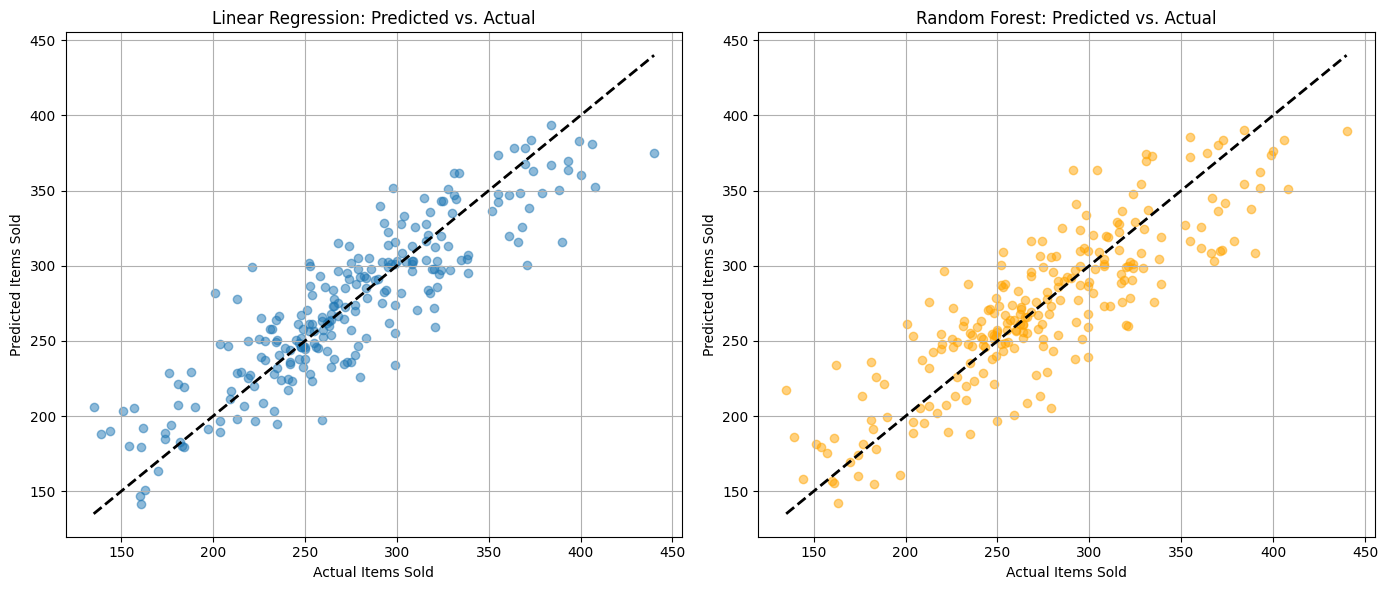

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

train_df = pd.read_csv('q3_train.csv')
test_df = pd.read_csv('q3_test.csv')

X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']
X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

# Building Preprocessor
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
                      'year', 'month', 'day_of_week', 'is_month_end']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

# 3. Assembling Pipelines
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_estimators=100))
])

# 4. Fitting and Predict
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

# 5. Evaluating Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)

print(f"Linear Regression - RMSE: {lr_rmse:.2f}, MAE: {lr_mae:.2f}")
print(f"Random Forest     - RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}")

# 6. Extracting Feature Importances (Random Forest)
cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_cols = numerical_features + list(cat_cols)

importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_cols, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

print("\nTop 5 Most Influential Features:")
print(feat_imp_df.head(5))

plt.figure(figsize=(14, 6))

# Parity Plot for Linear Regression
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(y_test, lr_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal reference line
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Linear Regression: Predicted vs. Actual')
plt.grid(True)

# Parity Plot for Random Forest
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(y_test, rf_preds, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal reference line
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Random Forest: Predicted vs. Actual')
plt.grid(True)

plt.tight_layout()
plt.show()